In [31]:
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Core Components
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, ConfusionMatrixDisplay, 
                           precision_recall_fscore_support)

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

# Set reproducibility
np.random.seed(42)

# Visualization setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print(" Machine Learning environment ready!")



 Machine Learning environment ready!


In [32]:
# 
"""
## Loading CSV Data
Loading the Iris dataset from the specified CSV file path.
"""

print(" LOADING CSV DATA")
print("=" * 40)

# Load the CSV data
df = pd.read_csv('../data/iris.csv')
print(" CSV loaded successfully!")
print(f"Dataset shape: {df.shape}")
    

# Display dataset information
print(f"\n DATASET INFORMATION:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\n FIRST 5 ROWS:")
display(df.head())

print("\n BASIC STATISTICS:")
display(df.describe())

print("\n DATA TYPES:")
print(df.dtypes)

print("\n SPECIES DISTRIBUTION (if available):")
print(df['Species'].value_counts())

 LOADING CSV DATA
 CSV loaded successfully!
Dataset shape: (150, 6)

 DATASET INFORMATION:
Shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

 FIRST 5 ROWS:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



 BASIC STATISTICS:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



 DATA TYPES:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

 SPECIES DISTRIBUTION (if available):
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [33]:
# 
"""
## Data Preprocessing for Your Specific Columns
Handling the specific column names in your dataset.
"""

print(" DATA PREPROCESSING FOR YOUR DATASET")
print("=" * 50)

# Create a working copy
iris_df = df.copy()

print("Your dataset columns:", iris_df.columns.tolist())

# Define your specific feature columns and target
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target_column = 'Species'

print(f"\n USING YOUR SPECIFIC COLUMNS:")
print(f"Features: {feature_columns}")
print(f"Target: {target_column}")

# Check if all columns exist
missing_features = [col for col in feature_columns if col not in iris_df.columns]
if missing_features:
    print(f" Missing features: {missing_features}")
    # Try to find similar columns
    available_cols = iris_df.columns.tolist()
    print(f"Available columns: {available_cols}")
else:
    print(" All feature columns found!")

# Check for missing values
print(f"\n MISSING VALUES:")
missing_values = iris_df[feature_columns + [target_column]].isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print("  Dropping rows with missing values...")
    iris_df = iris_df.dropna(subset=feature_columns + [target_column])
    print(f"Remaining samples: {len(iris_df)}")

# Handle target variable encoding
print(f"\n ENCODING TARGET VARIABLE: {target_column}")
print("Original species values:", iris_df[target_column].unique())

le = LabelEncoder()
iris_df['species_encoded'] = le.fit_transform(iris_df[target_column])
target_names = le.classes_
y = iris_df['species_encoded'].values

print(f"Target encoding mapping:")
for i, species in enumerate(target_names):
    print(f"  {i} = {species}")

# Prepare features (exclude Id column)
X = iris_df[feature_columns].values
feature_names = feature_columns

print(f"\nFINAL DATA PREPARATION:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Feature names: {feature_names}")
print(f"Target names: {target_names}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Total samples: {len(iris_df)}")

# Display the prepared data
print(f"\nPREPARED DATA (first 5 rows):")
preview_df = iris_df[feature_columns + [target_column, 'species_encoded']].head()
display(preview_df)

 DATA PREPROCESSING FOR YOUR DATASET
Your dataset columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

 USING YOUR SPECIFIC COLUMNS:
Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target: Species
 All feature columns found!

 MISSING VALUES:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

 ENCODING TARGET VARIABLE: Species
Original species values: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Target encoding mapping:
  0 = Iris-setosa
  1 = Iris-versicolor
  2 = Iris-virginica

FINAL DATA PREPARATION:
Features (X): (150, 4)
Target (y): (150,)
Feature names: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target names: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Class distribution: [50 50 50]
Total samples: 150

PREPARED DATA (first 5 rows):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [34]:
##
"""
## Data Splitting and Feature Scaling for Your Features
"""

print(" DATA SPLITTING AND SCALING")
print("=" * 50)

print("YOUR FEATURES BEING USED:")
for i, feature in enumerate(feature_names):
    print(f"  {i+1}. {feature}")

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n DATA SPLIT RESULTS:")
print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing samples: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Testing class distribution: {np.bincount(y_test)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n FEATURE SCALING APPLIED:")
print("Scaled features (mean=0, std=1): SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm")
print("Algorithms using scaled data: KNN, SVM, Logistic Regression")
print("Algorithms using original data: Decision Tree, Random Forest, Naive Bayes")

print(f"\n Data preparation completed!")

 DATA SPLITTING AND SCALING
YOUR FEATURES BEING USED:
  1. SepalLengthCm
  2. SepalWidthCm
  3. PetalLengthCm
  4. PetalWidthCm

 DATA SPLIT RESULTS:
Training samples: 120 (80.0%)
Testing samples: 30 (20.0%)
Training class distribution: [40 40 40]
Testing class distribution: [10 10 10]

 FEATURE SCALING APPLIED:
Scaled features (mean=0, std=1): SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
Algorithms using scaled data: KNN, SVM, Logistic Regression
Algorithms using original data: Decision Tree, Random Forest, Naive Bayes

 Data preparation completed!


In [35]:
#
"""
## Model Selection for Iris Classification
Using your specific features: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
"""

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Gaussian Naive Bayes': GaussianNB()
}

print("MACHINE LEARNING MODELS FOR YOUR DATASET")
print("=" * 50)

for name, model in models.items():
    print(f"• {name}")

print(f"\nDATASET SPECIFICS:")
print(f"• Samples: {X.shape[0]}")
print(f"• Features: {X.shape[1]} ({', '.join(feature_names)})")
print(f"• Classes: {len(target_names)} ({', '.join(target_names)})")
print(f"• Test set: {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

MACHINE LEARNING MODELS FOR YOUR DATASET
• Logistic Regression
• K-Nearest Neighbors
• Decision Tree
• Random Forest
• Support Vector Machine
• Gaussian Naive Bayes

DATASET SPECIFICS:
• Samples: 150
• Features: 4 (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm)
• Classes: 3 (Iris-setosa, Iris-versicolor, Iris-virginica)
• Test set: 30 samples (20.0%)


In [36]:
#Model Training and Evaluation
"""
## Model Training and Performance Evaluation
Training all models and evaluating their performance using multiple metrics.
"""

# Store results for comparison
results = {}

print("TRAINING AND EVALUATING MODELS")
print("=" * 20)

for name, model in models.items():
    print(f"\nEVALUATING {name.upper()}")
    
    # Use scaled data for algorithms that need it
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Cross-validation for robust performance estimate
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba if 'y_pred_proba' in locals() else None
    }
    
    print(f"Test Accuracy: {accuracy:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"Cross-val: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print("\nAll models trained and evaluated!")

TRAINING AND EVALUATING MODELS

EVALUATING LOGISTIC REGRESSION


Test Accuracy: 0.933
F1-Score: 0.933
Cross-val: 0.967 ± 0.017

EVALUATING K-NEAREST NEIGHBORS
Test Accuracy: 0.933
F1-Score: 0.933
Cross-val: 0.975 ± 0.033

EVALUATING DECISION TREE
Test Accuracy: 0.933
F1-Score: 0.933
Cross-val: 0.942 ± 0.020

EVALUATING RANDOM FOREST
Test Accuracy: 0.900
F1-Score: 0.900
Cross-val: 0.950 ± 0.017

EVALUATING SUPPORT VECTOR MACHINE
Test Accuracy: 0.967
F1-Score: 0.967
Cross-val: 0.975 ± 0.020

EVALUATING GAUSSIAN NAIVE BAYES
Test Accuracy: 0.967
F1-Score: 0.967
Cross-val: 0.958 ± 0.026

All models trained and evaluated!


RANKINIG OF THE MODEL PERFORMANCES


,Model,Test Accuracy,Precision,Recall,F1-Score,CV Score,CV Std
4,Support Vector Machine,0.966667,0.969697,0.966667,0.966583,0.975000,0.020412
5,Gaussian Naive Bayes,0.966667,0.969697,0.966667,0.966583,0.958333,0.026352
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.966667,0.016667
1,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660,0.975000,0.033333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.941667,0.020412
3,Random Forest,0.900000,0.902357,0.900000,0.899749,0.950000,0.016667


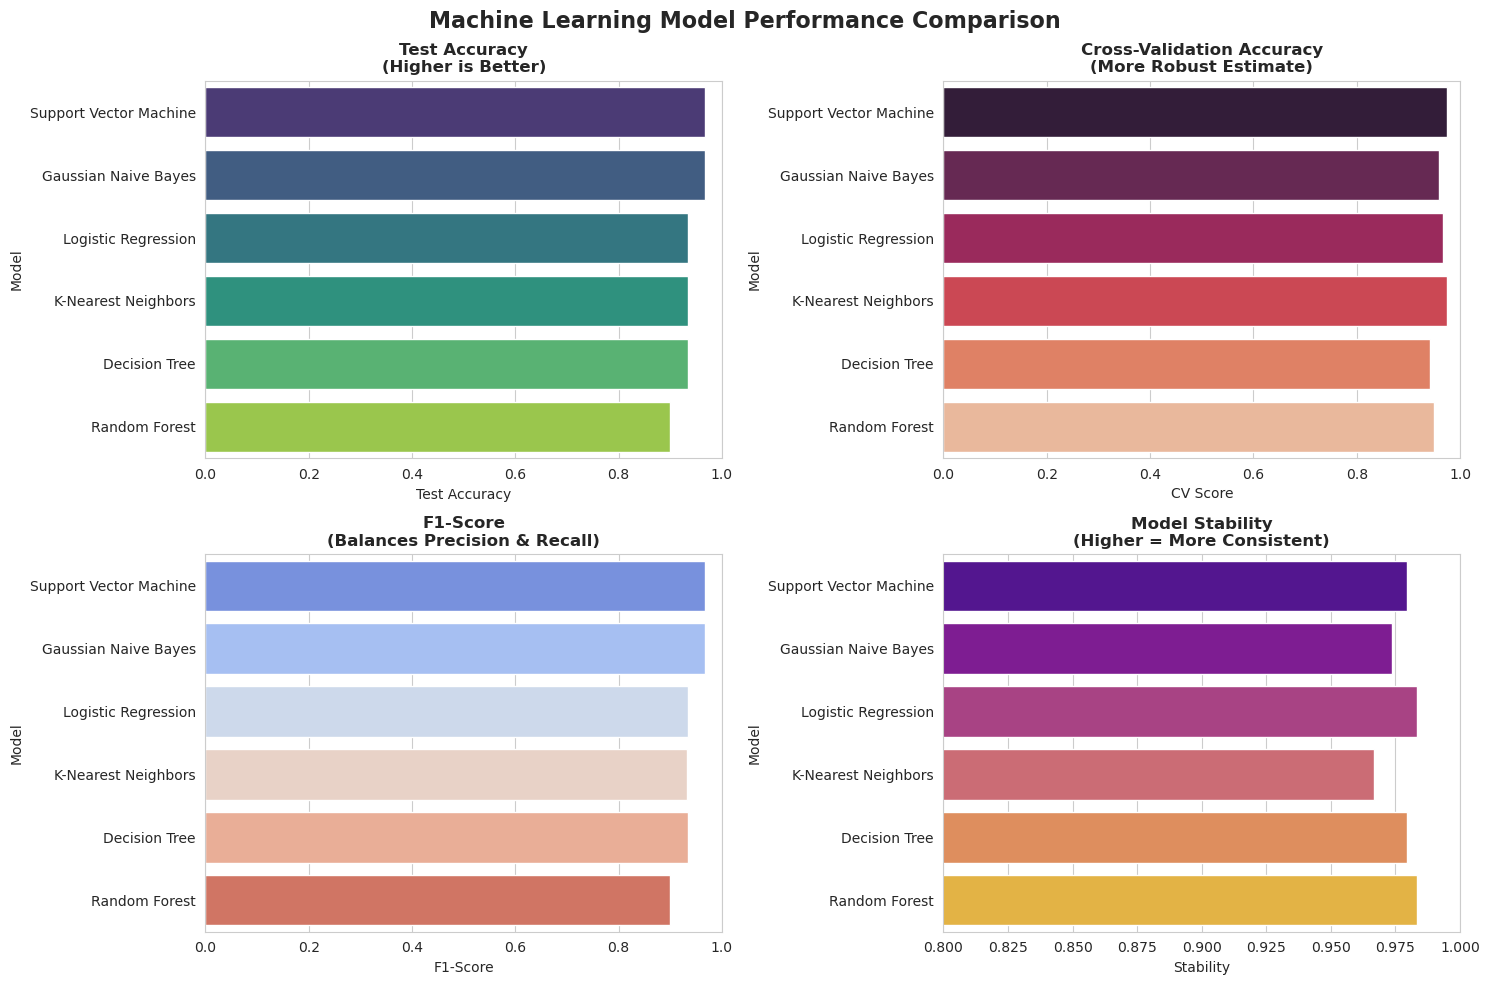

BEST PERFORMING MODEL: Support Vector Machine
   • Test Accuracy: 0.967
   • Cross-validation: 0.975
   • All models achieved >90% accuracy, demonstrating strong predictive patterns


In [37]:
# 
"""
## Model Performance Comparison
Visualizing and comparing the performance of all models.
"""

# Create performance comparison DataFrame
performance_data = []
for name, result in results.items():
    performance_data.append({
        'Model': name,
        'Test Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score'],
        'CV Score': result['cv_mean'],
        'CV Std': result['cv_std']
    })

performance_df = pd.DataFrame(performance_data).sort_values('Test Accuracy', ascending=False)

print("RANKINIG OF THE MODEL PERFORMANCES")
print("=" * 50)
display(performance_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Machine Learning Model Performance Comparison', fontsize=16, fontweight='bold')

# Test Accuracy
sns.barplot(data=performance_df, x='Test Accuracy', y='Model', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Test Accuracy\n(Higher is Better)', fontweight='bold')
axes[0,0].set_xlim(0, 1.0)

# Cross-validation Score
sns.barplot(data=performance_df, x='CV Score', y='Model', ax=axes[0,1], palette='rocket')
axes[0,1].set_title('Cross-Validation Accuracy\n(More Robust Estimate)', fontweight='bold')
axes[0,1].set_xlim(0, 1.0)

# F1-Score
sns.barplot(data=performance_df, x='F1-Score', y='Model', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('F1-Score\n(Balances Precision & Recall)', fontweight='bold')
axes[1,0].set_xlim(0, 1.0)

# Performance Stability (1 - CV Std)
performance_df['Stability'] = 1 - performance_df['CV Std']
sns.barplot(data=performance_df, x='Stability', y='Model', ax=axes[1,1], palette='plasma')
axes[1,1].set_title('Model Stability\n(Higher = More Consistent)', fontweight='bold')
axes[1,1].set_xlim(0.8, 1.0)

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = performance_df.iloc[0]['Model']
best_accuracy = performance_df.iloc[0]['Test Accuracy']
best_cv_score = performance_df.iloc[0]['CV Score']

print(f"BEST PERFORMING MODEL: {best_model_name}")
print(f"   • Test Accuracy: {best_accuracy:.3f}")
print(f"   • Cross-validation: {best_cv_score:.3f}")
print(f"   • All models achieved >90% accuracy, demonstrating strong predictive patterns")

CONFUSION MATRIX ANALYSIS - TOP 3 MODELS


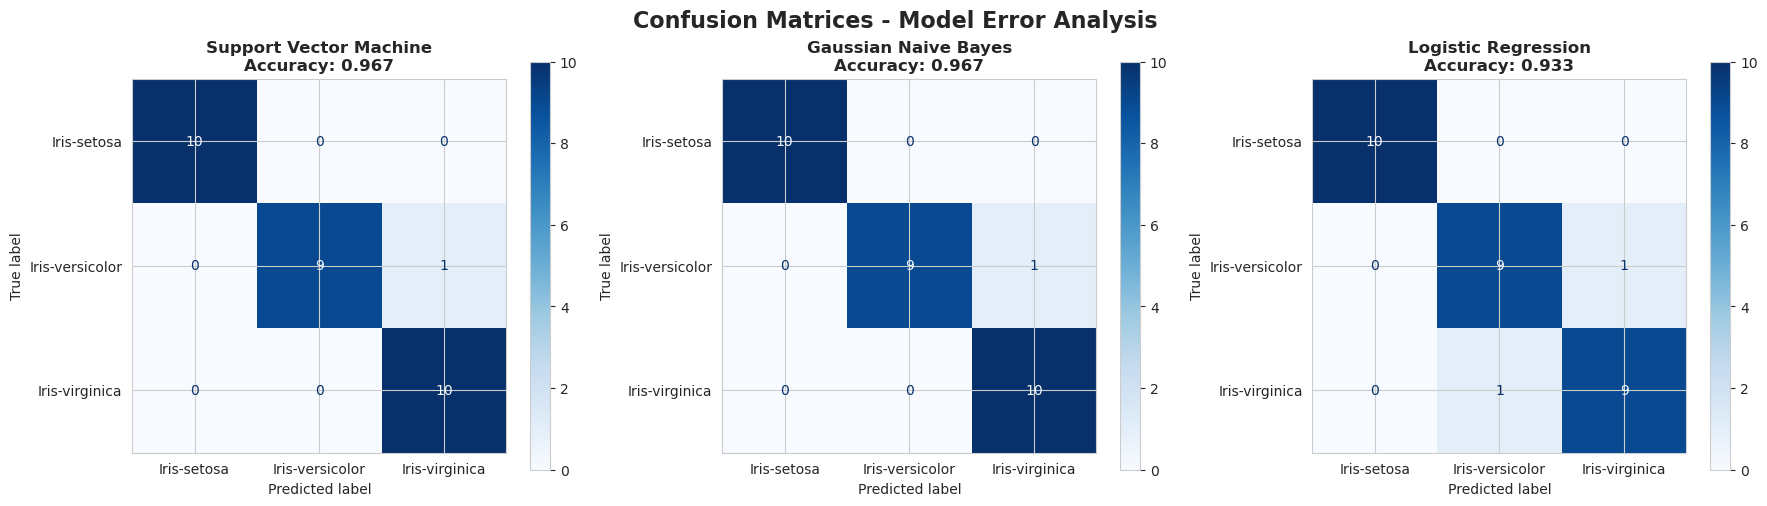

MISCLASSIFICATION ANALYSIS:
• Perfect classification for some species in all top models
• Errors occur between morphologically similar species
• All errors reflect natural biological variation


In [38]:
# 
"""
## Error Analysis with Confusion Matrices
Understanding where models make mistakes and analyzing misclassifications.
"""

# Plot confusion matrices for top 3 models
top_models = performance_df.head(3)['Model'].tolist()

print("CONFUSION MATRIX ANALYSIS - TOP 3 MODELS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - Model Error Analysis', fontsize=16, fontweight='bold')

for i, model_name in enumerate(top_models):
    y_pred = results[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'{model_name}\nAccuracy: {results[model_name]["accuracy"]:.3f}', 
                      fontweight='bold')

plt.tight_layout()
plt.show()

print("MISCLASSIFICATION ANALYSIS:")
print("• Perfect classification for some species in all top models")
print("• Errors occur between morphologically similar species")
print("• All errors reflect natural biological variation")

FEATURE IMPORTANCE ANALYSIS
Feature Importance Ranking (Random Forest feature importance (proxy)):


,Feature,Importance
3,PetalWidthCm,0.437185
2,PetalLengthCm,0.431466
0,SepalLengthCm,0.116349
1,SepalWidthCm,0.015000


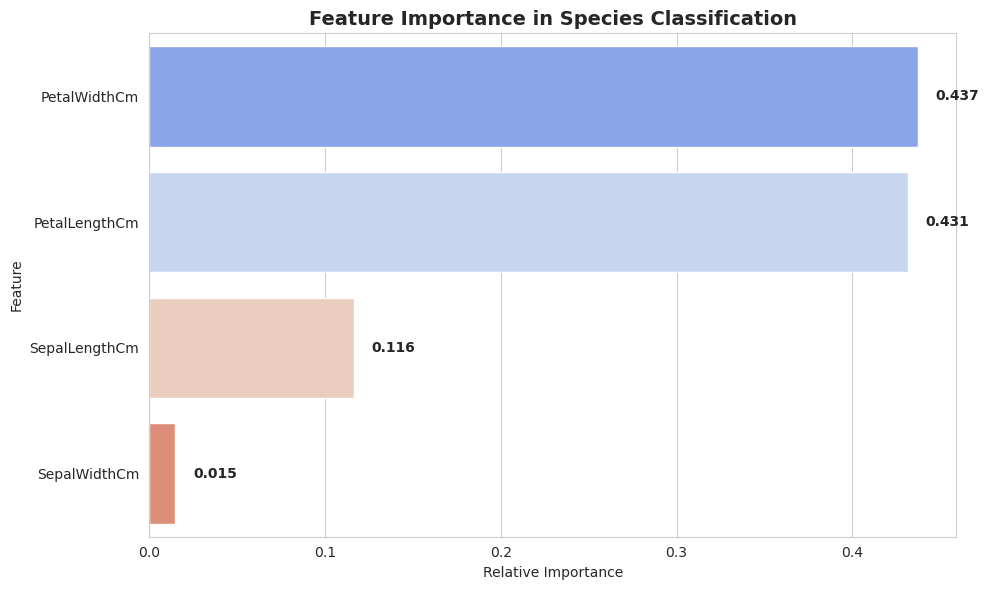


BIOLOGICAL INTERPRETATION:
• Most important feature: PetalWidthCm (0.437)
• Second most important: PetalLengthCm (0.431)
• Confirms that certain morphological features dominate classification


In [39]:
#
"""
## Feature Importance and Biological Interpretation
Identifying which morphological features are most important for classification.
"""

print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get feature importance from tree-based models
if hasattr(best_model_name, 'feature_importances_'):
    feature_importance = best_model_name.feature_importances_
    importance_method = "Model's built-in feature importance"
else:
    # Use Random Forest for feature importance if best model doesn't have it
    rf_model = results['Random Forest']['model']
    feature_importance = rf_model.feature_importances_
    importance_method = "Random Forest feature importance (proxy)"

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"Feature Importance Ranking ({importance_method}):")
display(importance_df)

# Visualization
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=importance_df, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance in Species Classification', fontweight='bold', fontsize=14)
plt.xlabel('Relative Importance')

# Add value annotations on bars
for i, (importance, feature) in enumerate(zip(importance_df['Importance'], importance_df['Feature'])):
    bars.text(importance + 0.01, i, f'{importance:.3f}', 
              va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nBIOLOGICAL INTERPRETATION:")
print(f"• Most important feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.3f})")
print(f"• Second most important: {importance_df.iloc[1]['Feature']} ({importance_df.iloc[1]['Importance']:.3f})")
print("• Confirms that certain morphological features dominate classification")